# Notebook 02 — Experimentos Deep Learning — Sinal Raw (FordA)

Classificação binária com modelos DL usando o sinal raw (sem pré-processamento wavelet):
- **CNN** (Convolutional Neural Network)
- **LSTM** (Long Short-Term Memory)
- **CNN-LSTM** (Híbrido)
- **Transformer**

**Pipeline:** Sinal Raw (500,1) → Grid Search → Avaliação (Accuracy, F1, AUC-ROC)

In [1]:
# GPU selection (must come BEFORE importing TensorFlow)
import os, sys
sys.path.append(".")
from config.experiment_config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR,
    DL_TRAINING_CONFIG, DL_MODELS_CONFIG,
    generate_dl_grid, SEED, GPU_ID, EPOCHS_OVERRIDE, MAX_GRID_CONFIGS,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
# Limitar a 1 GPU para evitar problemas de batch desigual com MirroredStrategy
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices([gpus[0]], 'GPU')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

from src.models import (
    create_cnn_model, create_lstm_model,
    create_cnn_lstm_model, create_transformer_model,
    get_callbacks, get_distribute_strategy,
)
from src.evaluation import ClassificationEvaluator, ResultsManager
from src.visualization import ExperimentVisualizer

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

strategy = get_distribute_strategy()

DL_RAW_DIR = RESULTS_DIR / "dl_raw_experiments"
DL_RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nSEED={SEED}")
if GPU_ID: print(f"GPU selecionada: {GPU_ID}")
if EPOCHS_OVERRIDE: print(f"EPOCHS_OVERRIDE={EPOCHS_OVERRIDE}")
if MAX_GRID_CONFIGS: print(f"MAX_GRID_CONFIGS={MAX_GRID_CONFIGS}")

I0000 00:00:1773061395.787036 3587567 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:5', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:6', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
⚡ MirroredStrategy: 1 GPUs

SEED=42


I0000 00:00:1773061397.655949 3587567 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8239 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


## 1. Carregar e Preparar Dados

In [2]:
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

# Adicionar dimensão de canal para DL
X_train = X_train[..., np.newaxis]  # (N, 500, 1)
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Dados Carregados (com canal):")
print(f"  Train: X={X_train.shape}, y={y_train.shape} (classe 1: {y_train.mean():.2%})")
print(f"  Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

input_shape = X_train.shape[1:]
print(f"\nInput shape para modelos: {input_shape}")

Dados Carregados (com canal):
  Train: X=(3060, 500, 1), y=(3060,) (classe 1: 48.73%)
  Val:   X=(541, 500, 1), y=(541,)
  Test:  X=(1320, 500, 1), y=(1320,)

Input shape para modelos: (500, 1)


## 2. Configuração

In [3]:
results_manager = ResultsManager(DL_RAW_DIR)
evaluator = ClassificationEvaluator()
viz = ExperimentVisualizer()

training_config = DL_TRAINING_CONFIG.copy()
print("Configuração de Treinamento:")
for k, v in training_config.items():
    print(f"  {k}: {v}")

all_results = {}          # melhor de cada arquitetura
all_histories = {}        # histórico do melhor
all_grid_results = []     # TODOS os resultados do grid

Configuração de Treinamento:
  epochs: 100
  batch_size: 64
  early_stopping_patience: 15
  reduce_lr_patience: 7
  reduce_lr_factor: 0.5
  min_lr: 1e-06
  verbose: 1


## 3. Experimento 1: CNN

In [4]:
print("=" * 70)
print("Grid Search: CNN com Sinal Raw")
print("=" * 70)

grid = generate_dl_grid("CNN")
base_params = DL_MODELS_CONFIG["CNN"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Raw_CNN_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"raw_cnn_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Raw_CNN", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Raw_CNN"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Raw_CNN"] = history.history
        model.save(str(MODELS_DIR / "raw_cnn_best.keras"))

    results_manager.log_experiment("DL_Raw", run_name, metrics, {"params": params})

print(f"\nMelhor CNN: {best_key} — Acc={best_acc:.4f}")


Grid Search: CNN com Sinal Raw

--- [1/36] Raw_CNN_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'filters': [32, 64, 128], 'kernel_sizes': [7, 5, 3]}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


I0000 00:00:1773061417.550584 3587567 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773061418.801880 3588165 cuda_dnn.cc:461] Loaded cuDNN version 91900


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 45: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 31.
    Acc=0.9402  F1=0.9396  AUC=0.9847  Time=

## 4. Experimento 2: LSTM

In [5]:
print("=" * 70)
print("Grid Search: LSTM com Sinal Raw")
print("=" * 70)

grid = generate_dl_grid("LSTM")
base_params = DL_MODELS_CONFIG["LSTM"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Raw_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"raw_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Raw_LSTM", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Raw_LSTM"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Raw_LSTM"] = history.history
        model.save(str(MODELS_DIR / "raw_lstm_best.keras"))

    results_manager.log_experiment("DL_Raw", run_name, metrics, {"params": params})

print(f"\nMelhor LSTM: {best_key} — Acc={best_acc:.4f}")


Grid Search: LSTM com Sinal Raw

--- [1/18] Raw_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'units': [64, 32]}

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
    Acc=0.6174  F1=0.6736  AUC=0.6408  Time=72.3s

--- [2/18] Raw_LSTM_g1: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'units': [128, 64]}

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.
    Acc=0.5205  F1=0.5436  AUC=0.5468  Time=49.1s

--- [3/18] Raw_LSTM_g2: {'dropout_rate': 0.2, 'l2_reg': 0.001, 'units': [64, 32]}

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.

## 5. Experimento 3: CNN_LSTM

In [6]:
print("=" * 70)
print("Grid Search: CNN_LSTM com Sinal Raw")
print("=" * 70)

grid = generate_dl_grid("CNN_LSTM")
base_params = DL_MODELS_CONFIG["CNN_LSTM"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Raw_CNN_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"raw_cnn_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Raw_CNN_LSTM", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Raw_CNN_LSTM"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Raw_CNN_LSTM"] = history.history
        model.save(str(MODELS_DIR / "raw_cnn_lstm_best.keras"))

    results_manager.log_experiment("DL_Raw", run_name, metrics, {"params": params})

print(f"\nMelhor CNN_LSTM: {best_key} — Acc={best_acc:.4f}")


Grid Search: CNN_LSTM com Sinal Raw

--- [1/36] Raw_CNN_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'cnn_filters': [32, 64], 'lstm_units': [64, 32]}

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 75: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 82: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 83: early stopping
Restoring model weights from the end of the best epoch: 68.
    Acc=0.9371  F1=0.9366  AUC=0.9821  Time=101.4s

--- [2/36] Raw_CNN_LSTM_g1: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'cnn_filters': [32, 64], 'lstm_units': [100, 50]}

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 57: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 81: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 88: ReduceLROnPlateau reducing learning 

## 6. Experimento 4: Transformer

In [8]:
print("=" * 70)
print("Grid Search: Transformer com Sinal Raw")
print("=" * 70)

grid = generate_dl_grid("Transformer")
base_params = DL_MODELS_CONFIG["Transformer"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Raw_Transformer_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_transformer_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"raw_transformer_g{gi}.keras")
    # Transformer usa WarmupSchedule, incompatível com ReduceLROnPlateau
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        use_reduce_lr=False,
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Raw_Transformer", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Raw_Transformer"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Raw_Transformer"] = history.history
        model.save(str(MODELS_DIR / "raw_transformer_best.keras"))

    results_manager.log_experiment("DL_Raw", run_name, metrics, {"params": params})

print(f"\nMelhor Transformer: {best_key} — Acc={best_acc:.4f}")

Grid Search: Transformer com Sinal Raw

--- [1/48] Raw_Transformer_g0: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.0001}
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 35.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=69.9s

--- [2/48] Raw_Transformer_g1: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.001}
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 26.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=58.0s

--- [3/48] Raw_Transformer_g2: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 3, 'l2_reg': 0.0001}
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=78.9s

--- [4/48] Raw_Transformer_g3: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 3, 'l2_reg': 0.001}
Epoch 36: early stopping
Resto

## 7. Comparação dos Resultados

In [9]:
# Tabela comparativa (melhor de cada arquitetura)
comp_rows = []
for name, info in all_results.items():
    row = {"Model": name, **info["metrics"],
           "Params": info["params"], "Time (s)": round(info["time"], 1),
           "Epochs": info["epochs"]}
    comp_rows.append(row)

comparison_df = pd.DataFrame(comp_rows).sort_values("accuracy", ascending=False)
comparison_df = comparison_df.set_index("Model")
print("\n" + "=" * 80)
print("COMPARAÇÃO DOS MODELOS DL (Raw Signal)")
print("=" * 80)
print(comparison_df.to_string())

comparison_df.to_csv(DL_RAW_DIR / "comparison_dl_raw.csv")
pd.DataFrame(all_grid_results).to_csv(DL_RAW_DIR / "all_grid_results_dl_raw.csv", index=False)
print(f"\nResultados salvos em {DL_RAW_DIR}")


COMPARAÇÃO DOS MODELOS DL (Raw Signal)
                 accuracy        f1  precision    recall   auc_roc  log_loss  specificity  Params  Time (s)  Epochs
Model                                                                                                              
Raw_CNN_LSTM     0.943939  0.942097   0.942097  0.942097  0.984307  0.163040     0.945668   54401     122.5     100
Raw_CNN          0.943182  0.942085   0.929878  0.954617  0.984054  0.159003     0.932452   60993     114.0      86
Raw_LSTM         0.718939  0.763845   0.643777  0.938967  0.752489  0.545887     0.512482  120193     103.2      45
Raw_Transformer  0.515909  0.000000   0.000000  0.000000  0.500000  0.692662     1.000000  191361      69.9      50

Resultados salvos em /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/dl_raw_experiments


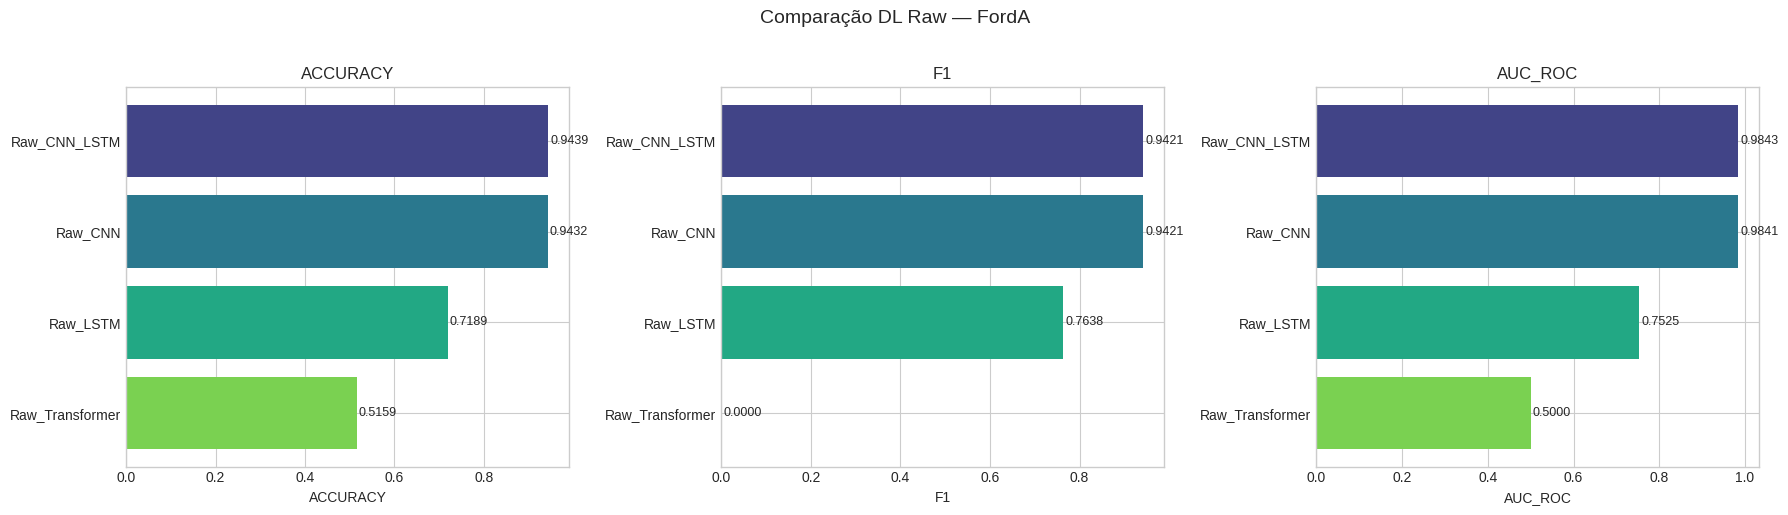

In [10]:
metrics_to_plot = ["accuracy", "f1", "auc_roc"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))

model_names = comparison_df.index.tolist()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))

for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].values
    bars = ax.barh(range(len(model_names)), values, color=colors)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names)
    ax.set_xlabel(metric.upper())
    ax.set_title(metric.upper())
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

fig.suptitle("Comparação DL Raw — FordA", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DL_RAW_DIR / "comparison_chart_dl_raw.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Evolução do Treinamento

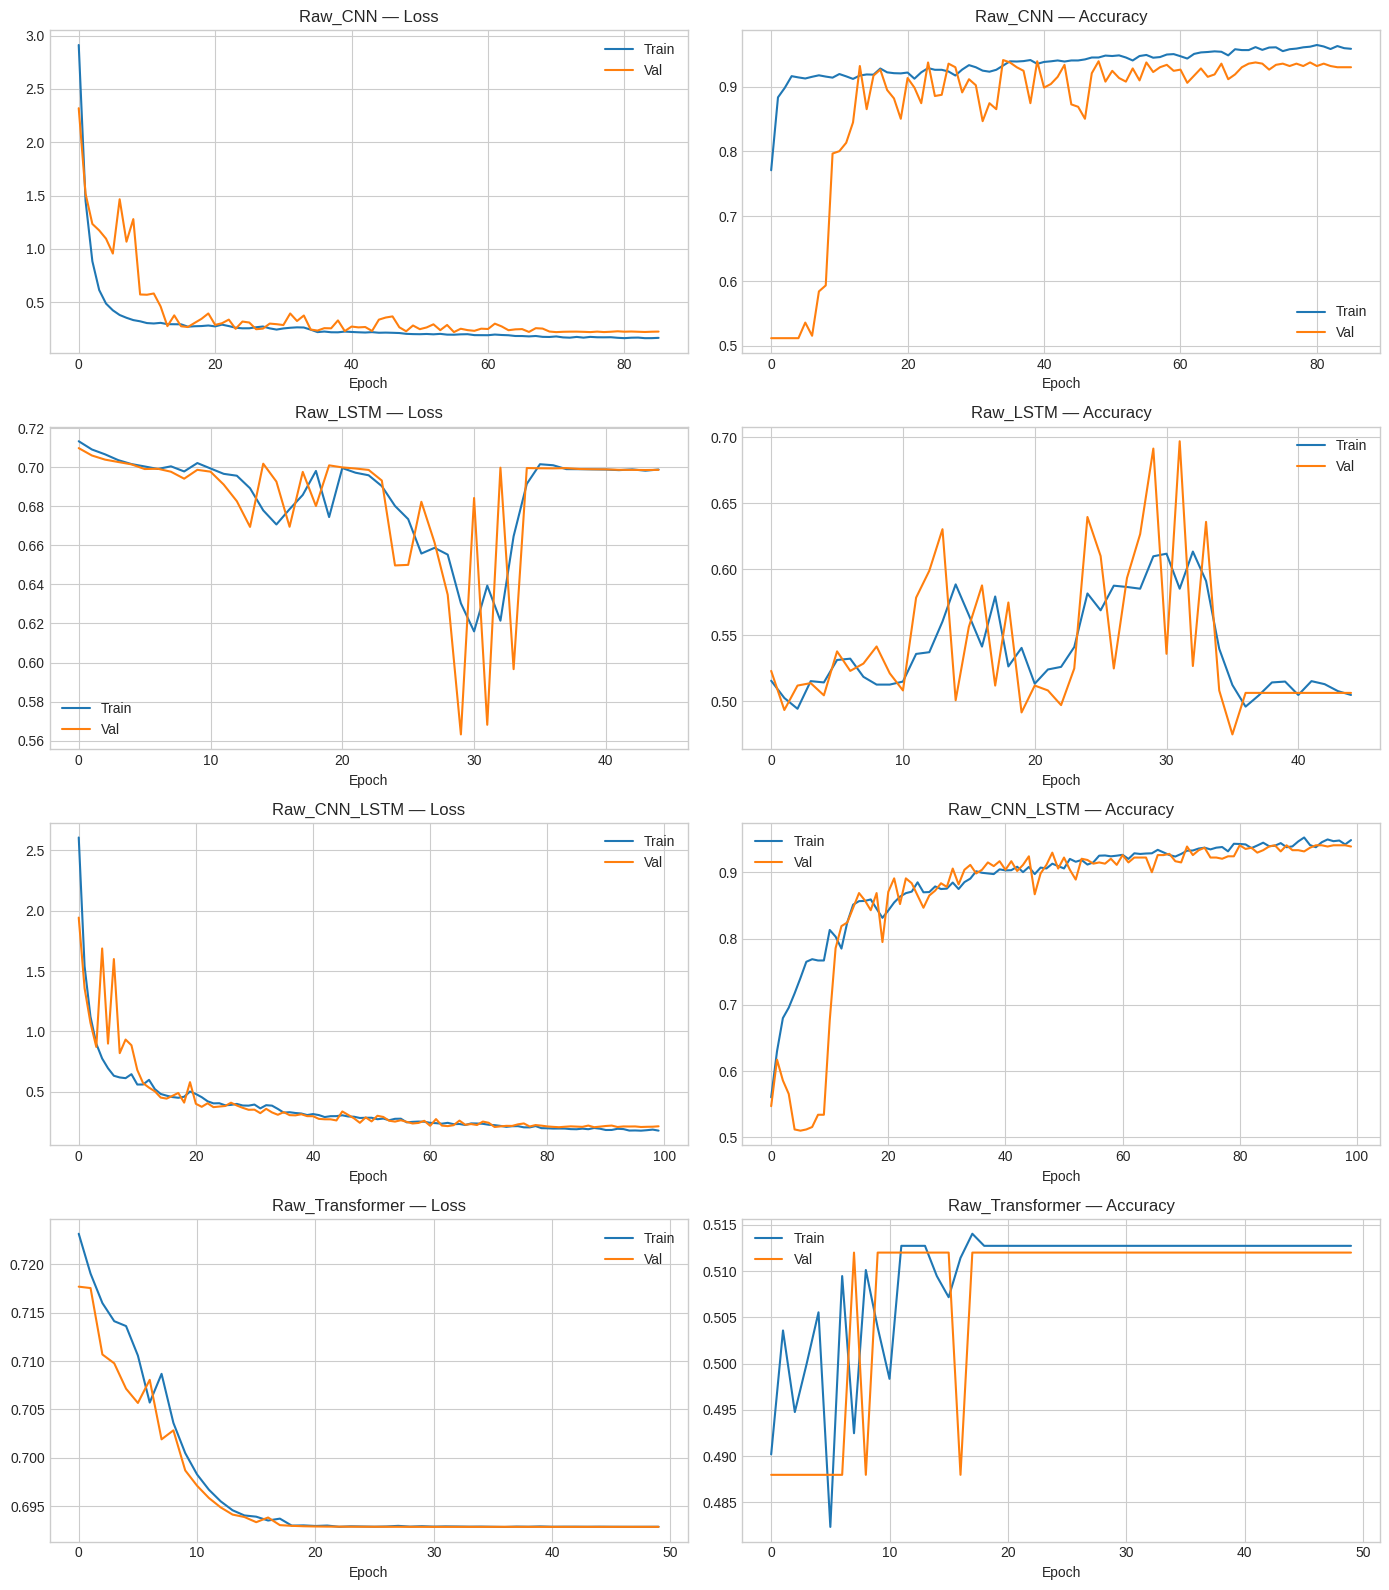

In [11]:
n_models = len(all_histories)
if n_models > 0:
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)

    for i, (name, hist) in enumerate(all_histories.items()):
        # Loss
        axes[i, 0].plot(hist["loss"], label="Train")
        axes[i, 0].plot(hist["val_loss"], label="Val")
        axes[i, 0].set_title(f"{name} — Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].legend()

        # Accuracy
        acc_key = "accuracy" if "accuracy" in hist else "acc"
        val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"
        if acc_key in hist:
            axes[i, 1].plot(hist[acc_key], label="Train")
            axes[i, 1].plot(hist[val_acc_key], label="Val")
            axes[i, 1].set_title(f"{name} — Accuracy")
            axes[i, 1].set_xlabel("Epoch")
            axes[i, 1].legend()

    plt.tight_layout()
    plt.savefig(DL_RAW_DIR / "training_evolution_dl_raw.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Confusion Matrices e ROC

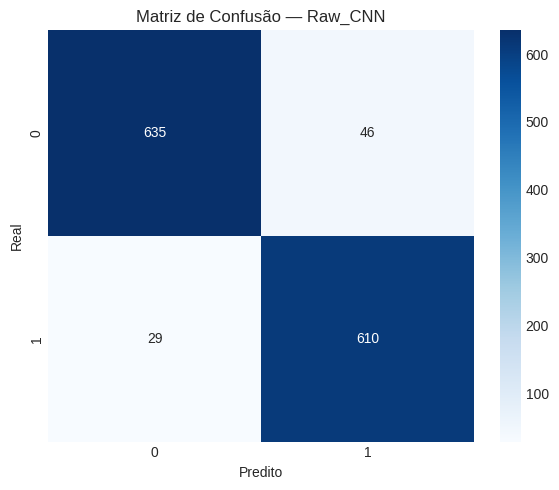

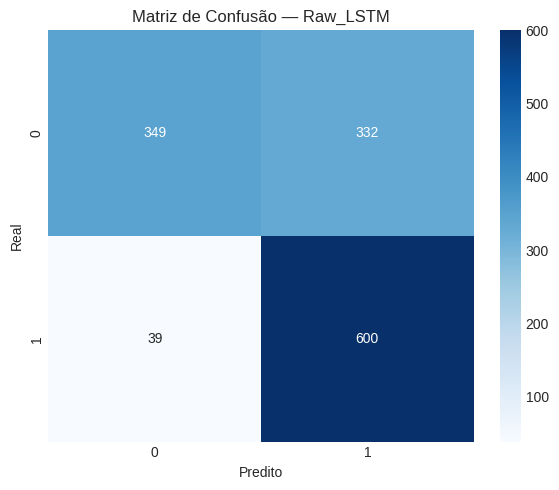

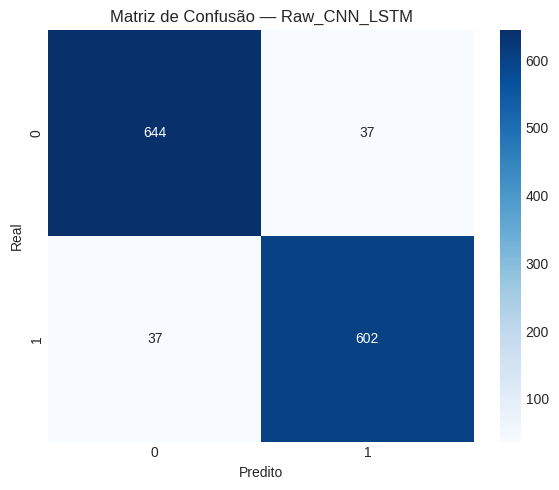

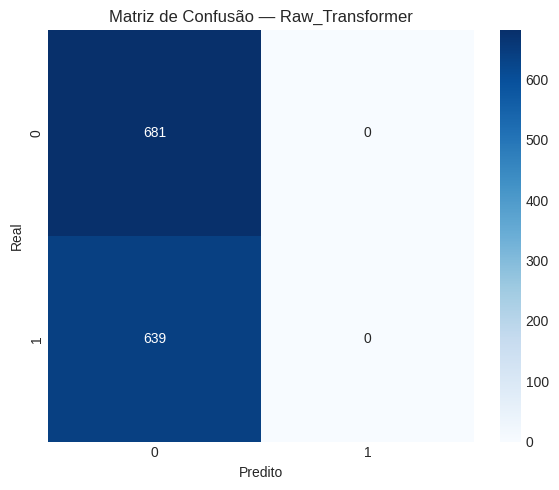

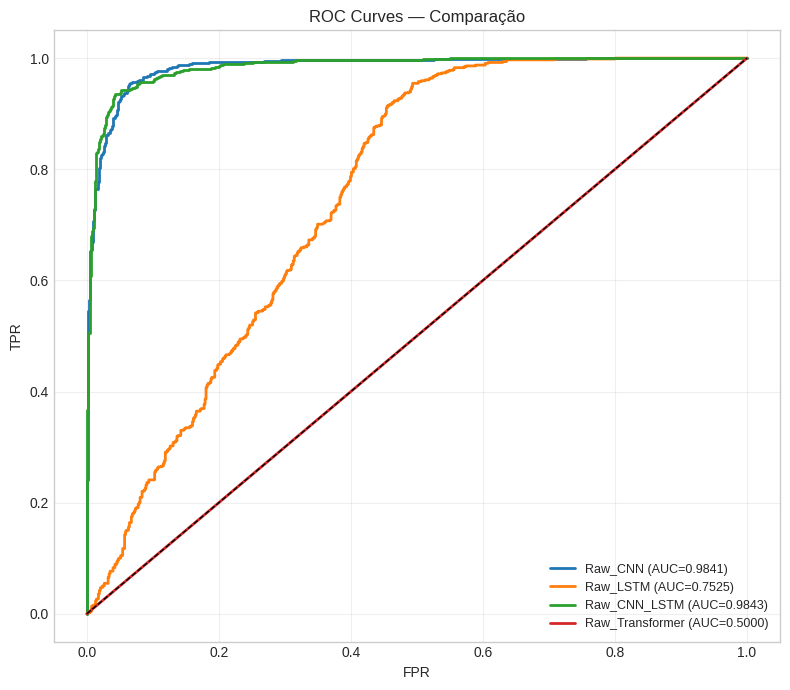

In [13]:
from sklearn.metrics import roc_curve, auc

# Confusion matrices do melhor de cada arquitetura
for name, info in all_results.items():
    viz.plot_confusion_matrix(
        y_test, info["y_pred"],
        model_name=name,
        save_path=DL_RAW_DIR / f"confusion_matrix_{name}.png",
    )
    plt.show()

# Multi-ROC
roc_data = {}
for name, info in all_results.items():
    if "y_prob" in info:
        fpr, tpr, _ = roc_curve(y_test, info["y_prob"])
        auc_val = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, auc_val)
if roc_data:
    viz.plot_multi_roc(
        roc_data,
        save_path=DL_RAW_DIR / "roc_curves_dl_raw.png",
    )
    plt.show()

## 10. Resumo

In [14]:
print("=" * 60)
print("RESUMO — DL Raw Experiments (FordA)")
print("=" * 60)
print(f"Arquiteturas avaliadas: {len(all_results)}")
print(f"Total de configurações grid: {len(all_grid_results)}")
if all_results:
    best_name = comparison_df.index[0]
    print(f"Melhor modelo: {best_name}")
    print(f"  Accuracy: {comparison_df.loc[best_name, 'accuracy']:.4f}")
    print(f"  F1:       {comparison_df.loc[best_name, 'f1']:.4f}")
    print(f"  AUC-ROC:  {comparison_df.loc[best_name, 'auc_roc']:.4f}")
print(f"Resultados em: {DL_RAW_DIR}")

RESUMO — DL Raw Experiments (FordA)
Arquiteturas avaliadas: 4
Total de configurações grid: 138
Melhor modelo: Raw_CNN_LSTM
  Accuracy: 0.9439
  F1:       0.9421
  AUC-ROC:  0.9843
Resultados em: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/dl_raw_experiments
